# Practica 2 - Ejercicio 5: Publicidad y ventas

**Enunciado:** Dataset `advertising.csv` con ventas de un producto en 200 mercados y presupuestos
publicitarios para TV, Radio y Periodicos. Determinar cual medio se asocia mas a las ventas,
ajustar el mejor modelo y analizar los residuos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
%matplotlib inline

In [2]:
df = pd.read_csv("../Datasets/Parte_2/advertising.csv")
print(df.head())
print(df.describe())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


## 1. Asociacion con ventas

Correlacion de Pearson con Sales:
  TV:        0.9012
  Radio:     0.3496
  Newspaper: 0.1580


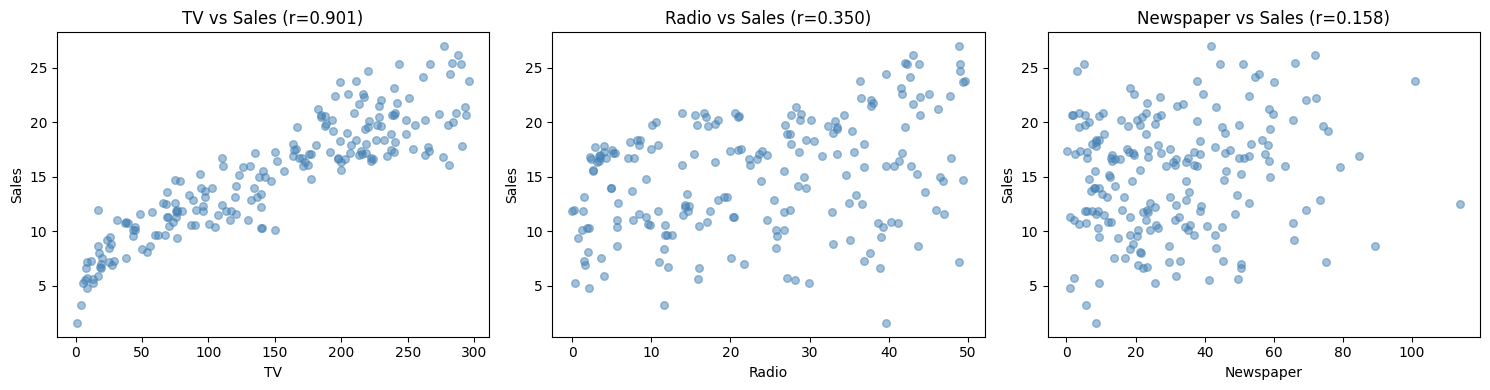

In [3]:
corr_tv    = df["TV"].corr(df["Sales"])
corr_radio = df["Radio"].corr(df["Sales"])
corr_news  = df["Newspaper"].corr(df["Sales"])
print("Correlacion de Pearson con Sales:")
print(f"  TV:        {corr_tv:.4f}")
print(f"  Radio:     {corr_radio:.4f}")
print(f"  Newspaper: {corr_news:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (var, r) in enumerate([("TV", corr_tv), ("Radio", corr_radio), ("Newspaper", corr_news)]):
    axes[i].scatter(df[var], df["Sales"], color="steelblue", alpha=0.5, s=30)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Sales")
    axes[i].set_title(f"{var} vs Sales (r={r:.3f})")
plt.tight_layout()
plt.show()

**TV** es el medio con mayor correlacion con las ventas (r ≈ 0.901), seguido de Radio (r ≈ 0.350)
y Periodicos (r ≈ 0.158).

## 2. Modelo completo y seleccion de variables

In [4]:
# Modelo completo
mod_full = smf.ols("Sales ~ TV + Radio + Newspaper", data=df)
res_full = mod_full.fit()
print("Modelo completo:")
print(res_full.summary())

print("\nSignificancia (alpha=0.05):")
for var, pv in res_full.pvalues.items():
    print(f"  {var}: p={pv:.4f} -> {'SIGNIFICATIVA' if pv < 0.05 else 'No significativa'}")

Modelo completo:
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           8.13e-99
Time:                        18:01:30   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6251      0.308   

In [5]:
# Newspaper no es significativa (p=0.954), se elimina
mod_red = smf.ols("Sales ~ TV + Radio", data=df)
res_red = mod_red.fit()
print("Modelo reducido (sin Newspaper):")
print(res_red.summary())

Modelo reducido (sin Newspaper):
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          2.39e-100
Time:                        18:01:30   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.63

## 3. Interpretacion del coeficiente TV

In [6]:
b_tv = res_red.params["TV"]
print(f"Coeficiente TV: {b_tv:.4f}")
print(f"Por cada unidad adicional ($1000) en presupuesto de TV,")
print(f"las ventas aumentan en promedio {b_tv:.4f} unidades.")
print(f"(equivale a {b_tv*1000:.2f} unidades por cada millon invertido en TV)")

Coeficiente TV: 0.0544
Por cada unidad adicional ($1000) en presupuesto de TV,
las ventas aumentan en promedio 0.0544 unidades.
(equivale a 54.45 unidades por cada millon invertido en TV)


## 4. Analisis de residuos

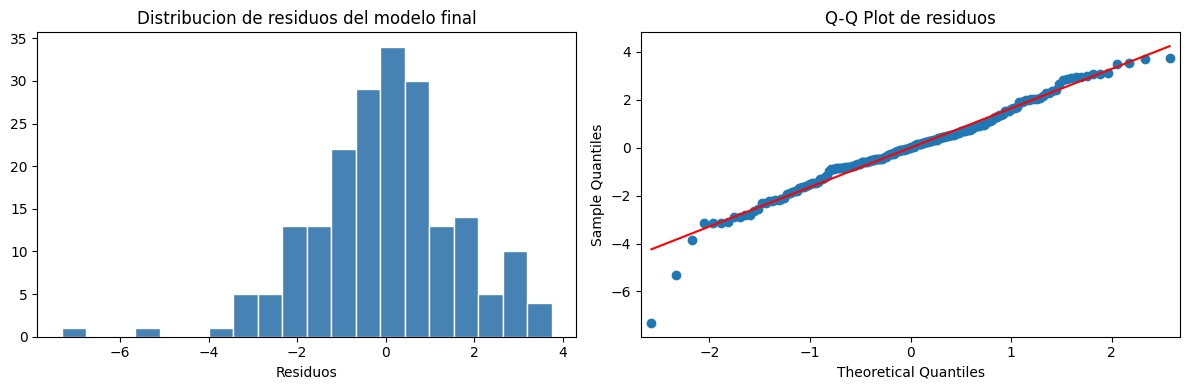

Test Shapiro-Wilk: W=0.9757, p-valor=0.0015
Conclusion: Se rechaza normalidad (p <= 0.05) - residuos con colas pesadas


In [7]:
residuos = res_red.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(residuos, bins=20, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Residuos")
axes[0].set_title("Distribucion de residuos del modelo final")

sm.qqplot(residuos, line="s", ax=axes[1])
axes[1].set_title("Q-Q Plot de residuos")
plt.tight_layout()
plt.show()

stat_sw, p_sw = stats.shapiro(residuos)
print(f"Test Shapiro-Wilk: W={stat_sw:.4f}, p-valor={p_sw:.4f}")
print("Conclusion:", "No se rechaza normalidad" if p_sw > 0.05
      else "Se rechaza normalidad (p <= 0.05) - residuos con colas pesadas")

## Conclusiones

- El medio mas asociado con las ventas es **TV** (r = 0.901).
- El modelo final (eliminando Newspaper, no significativo) es:

$$\hat{Sales} = 4.63 + 0.0544 \cdot TV + 0.1072 \cdot Radio$$

- **Coeficiente TV = 0.0544:** Por cada $1000 adicionales en publicidad televisiva, las ventas
  aumentan en promedio 54.4 unidades.
- **R² = 0.903:** El modelo explica el 90.3% de la variabilidad en ventas.
- **Residuos:** El test Shapiro-Wilk rechaza la normalidad (p < 0.05). El histograma y Q-Q plot
  muestran colas levemente pesadas, pero la desviacion de la normalidad no es grave.
  Con n=200, los estimadores son asintoticamante validos.